## 定义模型

In [ ]:
from langchain_community.chat_models import ChatTongyi
llm = ChatTongyi(
    model="qwen3-235b-a22b-instruct-2507", 
    dashscope_api_key=os.getenv("DASHSCOPE_API_KEY"),
)

## 定义节点

In [35]:
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from typing_extensions import Literal
from langchain.messages import HumanMessage, SystemMessage


# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="路由到的下一步分支"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)


# State
class State(TypedDict):
    input: str
    decision: str
    output: str


# Nodes
def llm_call_1(state: State):
    """Write a story"""
    messages = [
        SystemMessage(
            content="写一个100字的故事"
        ),
        HumanMessage(content=state["input"]),
    ]
    result = llm.invoke(messages)
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""
    messages = [
        SystemMessage(
            content="写一个20字的笑话"
        ),
        HumanMessage(content=state["input"]),
    ]
    result = llm.invoke(messages)
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""
    messages = [
        SystemMessage(
            content="写一首五言绝句"
        ),
        HumanMessage(content=state["input"]),
    ]
    result = llm.invoke(messages)
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="将输入路由到 joke, story, 或者是 poem"
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"

## 构建图

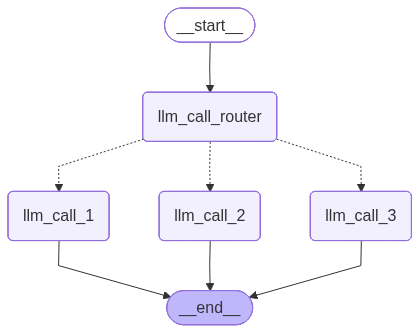

In [36]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))

## 运行

In [37]:
# Invoke
state = router_workflow.invoke({"input": "写一个关于猴子的诗"})
print(state["output"])

山深猴戏影，  
攀藤摘野果。  
忽闻人声近，  
跃入云中躲。
